# Neural Networks Assignment, 2025 A2 <ignore>
## Overview
In this assessment, you will be asked to carry out three tasks. The first task involves building and training a simple CNN-based classifier for the Fashion MNIST dataset, and demonstrating the effectiveness of a technique to improve gradient flow. The second task involves building and training an unconditional GAN to generate images that look like those in the Fashion MNIST dataset, and using the discriminator to investigate the quality of the generated images. The third task involves augmenting the GAN to improve the generated images in some way.

## Instructions
### Code and Markdown cells
All of your report, including code and Markdown/text, ***must*** be written up in ***this*** notebook. Please make sure you change the title of this file so that XXXXXX is replaced by your candidate number. You can use code cells, where provided, to write code to implement, train, test, and analyse your NNs, as well as to generate figures to plot data and the results of your experiments. If you wish to add more code cells, you may do so immediately after the code cells that have been provided, but do not add any code cells anywhere else in this file. You must use the Markdown/text cells that are provided for writing the three report sections, one for each Task. These Markdown cells have "*Replace this text with your report for Task X*" in italics. Please replace that text with your own text. So that we can mark your reports with greater consistency, please ***do not***:

* add any of your own Markdown cells.
* rearrange the sequence of cells in this notebook.
* delete any cells, including the ones explaining what you need to do.

### Plotting figures
All plots of data ***must*** be produced as output from a code cell. Any plots that have been imported as images, rather than being the output of a plot function (such as that provided by matplotlib) will not receive marks. This is to ensure that you did the work to produce that plot. All figures should have an accompanying caption that states the Figure number and a detailed description of what the figure shows (see the guidenace in the file ```useful_code_for_figures_equations.ipynb```). 

### Writing code
Where relevant in your written report, e.g. when describing your methods, indicate where in your code the methods are implemented, including  the cell and line numbers (if you use VSCode, these are visible in the bottom right corner of the window). You might say, for example, "_layers 1-4 used 3x3 convolutional filters with a stride of 1 and padding of 1 (cell 5, line 30)_".  Please provide verbose comments throughout your code so that it is easy for us to interpret what you are attempting to achieve. Long comments are useful at the beginning of a block of code. Short comments, e.g. to explain the purpose of a new variable, or one of several steps in some analyses, are useful on every few lines of code, if not on every line. Please do not use the code cells for writing verbose responses to subtasks, which should instead be written in the provided Markdown cells.

# TASK 1 <ignore>

The classifier was trained for 10 epochs with 10 output classes, batch size 64, and initial learning rate 0.001. The model ran in CUDA when available, otherwise, CPU was used.
The training and test data were preprocessed before loading, beginning with the creation of a transform variable, used later, and uses `ToTensor()` and `Normalize((0.5,), (0.5,))`. `ToTensor()` rescales pixel values from 0-255 to 0-1, then `Normalize()` centres the pixels around 0, in range <lt>$[-1, 1]$, using mean and standard deviation of 0.5. `Normalize()` subtracts 0.5, then divides by 0.5 to achieve this, represented by:
<lt>$$ x_{\text{norm}} = \frac{x - \mu}{\sigma} $$
where <lt>$x$ is the pixel value after `ToTensor()` has been applied.

The Fashion-MNIST dataset has 10,000 testing and 60,000 training images, each a 28x28 grayscale image. The training loader used `shuffle=True` to randomise batches each epoch, but the test set does not require randomisation, so `shuffle=False`. Both datasets are transformed, and the loaders have a batch size of 64.

The CNN takes 28x28 grayscale inputs and provides a 10-dimensional output for multiclass classification scores. The network contains five convolutional layers implemented with `nn.Module` and `nn.Sequential`. Each layer begins with `nn.Conv2d(x, y, kernel, stride, padding)`. The kernel size is 5, stride is 1, and padding is 2 for all layers, providing a 5x5 filter size. The first layer maps 1 input channel to 16 filters, learning local image features such as edges, shapes, and textures. `BatchNorm2d()` then normalises the feature maps produced, with 16 (y) used. ReLU activation is applied, introducing non-linearity by replacing negative values with 0. The ReLU activation function is:
<lt>$$ ReLU(x) = max(0, x) $$

This process is repeated throughout all five convolutional layers, with x and y in `Conv2d()` increased each time: (16, 32), (32, 64), (64, 128), and (128, 128) respectively. `BatchNorm2d()` is also updated with the new y value. The y value increases with each layer, until it reaches 128, providing double the amount of filters each pass, except for the final pass.
The first two layers also incorporate `MaxPool2d(kernel, stride)`, which reduces the spatial size. After layer 1, the feature map shape is 16x14x14. After layer 2 it is 32x7x7. The convolutional layers preserve spatial size because padding 2 is used with a 5x5 kernel, so spatial reduction comes from the two max-pooling layers. From here, the spatial size remains the same, but the number of filters increases (y value), until it reaches 128x7x7.
After the fifth layer, it is flattened and reshaped through `nn.Linear(128*7*7, 10)`, where 10 is the number of classes, and 128*7*7 is the feature-map size. The final layer outputs 10 logits, one for each Fashion MNIST class. A softmax was not manually applied during training because PyTorch's `CrossEntropyLoss` applies the required log-softmax operation internally.

The model was trained using `CrossEntropyLoss`, which is suitable for multiclass classification as it compares the 10 output logits with the correct class label, alongside an `Adam` optimiser. For each batch, the model performed a forward pass, calculated the loss, backpropagated the gradients, updated the parameters using Adam, and then reset the gradients before the next batch. The cross entropy loss over a batch is:
<lt>$$ L = -\frac{1}{N_s}\sum_{i=1}^{N_s}\sum_{c=1}^{N_c}\mathbb{I}[y_i = c]\log p(y_i \mid x_i) $$
where <lt>$N_s$ is the number of samples in the batch, <lt>$N_c = 10$ and is number of classes, <lt>$\mathbb{I}[y_i = c]$ is 1 when class c is correct, 0 otherwise, and <lt>$p(y_i \mid x_i)$ is softmax probability assigned to class <lt>$c$.

During testing, the model was set to evaluation mode and gradients were disabled using `torch.no_grad()`. The predicted class was selected as the class with the largest output logit, with accuracy calculated as:
<lt>$$ \text{Accuracy} = \frac{\text{Number of Correct Predictions}}{\text{Total Number of Predictions}} \times 100$$ 

### Experiment 1:
| Learning Rate | | 0.1 | 0.05 | 0.01 | 0.005 | 0.001 | 0.0005 | 0.0001 |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| Accuracy (%) | Test 1 | 89.6 | 89.68 | 91.18 | 90.59 | 91.97 | 91.06 | 89.86 |
|	           | Test 2	| 90.49 | 89.99 | 91.29 | 91.5 | 92 | 91.43 | 89.71 |
|	           | Test 3	|89.51 | 90.2 | 90.69 | 91.7 | 91.77 | 91.15 | 89.6 |
| Average Accuracy (%)| | 89.87 | 89.96 | 91.05 | 91.26 | 91.91 | 91.21 | 89.72 |

*Table 1: Results for Experiment 1, where different learning rates were used to determine which gave the highest average accuracy.*

### Experiment 2:
| | | with `BatchNorm2d()` | without `BatchNorm2d()` |
|---|---:|---:|---:|
| Accuracy (%) | Test 1 | 91.49 | 90.79 |
|	           | Test 2 | 91.81 | 90.95 |
|	           | Test 3 | 91.74 | 90.75 |
| Average Accuracy (%) | | 91.68 | 90.83 |

*Table 2: Results for Experiment 2, evaluating the difference between the implementation of `BatchNorm2d()` and without it.*

### Experiment 3:
| | | with `Normalize()` | without `Normalize()` |
|---|---:|---:|---:|
| Accuracy (%) | Test 1 | 91.72 | 91.39 |
|	           | Test 2 | 91.17 | 91.65 |
|	           | Test 3 | 92.19 | 92.15 |
| Average Accuracy (%) | | 91.69 | 91.73 |

*Table 3: Results for Experiment 3, assessing the accuracy when `Normalize()` is used during preprocessing compared to when it is not.*

Three experiments were conducted in total, each with three tests per parameter to obtain an average. Each test ran separately, but with 10 epochs and the same architecture.
The first experiment determined which learning rate provided the highest accuracy, using values 0.1, 0.05, 0.01, 0.005, 0.001, 0.0005, and 0.0001. Values 0.1, 0.05, and 0.0001 all gave an accuracy below 90%, although only just, with 0.0001 being the lowest with 89.72%. In contrast, the remaining values all had an accuracy over 91%, with 0.001 having the highest average accuracy, with 91.91%, 0.65 higher than the next best learning rate (Table 1). 
Experiment 2 observed whether removing `BatchNorm2d()` from each layer of the CNN would affect the accuracy. A learning rate of 0.001 was used, as it previously gave the best accuracy. The results showed that removing `BatchNorm2d()` led to an average accuracy of 90.83%, which was noticeably lower than when it was included, where an accuracy of 91.68% was achieved (Table 2), aligning with Ioffe and Szegedy's 2015 paper [4].
The final experiment determined whether normalising the pixels during preprocessing would affect the overall accuracy. The average accuracy only had a 0.04% difference, with no normalisation being negligibly higher at 91.73%, suggesting that this additional preprocessing step had very little effect (Table 3).

Overall, the best-performing configurations used a learning rate of 0.001 and applied `BatchNorm2d()` in each layer. The best average accuracy achieved was 91.91%, while the highest individual test accuracy was 92.19% during Experiment 3. This exceeded the target of 90% for 'Good Performance'. Batch normalisation improved classification accuracy, whereas preprocessing normalisation had a negligible effect. One limitation is that the accuracy was reported overall rather than per class, so the model may have performed better on distinct items, such as Sneakers, compared to similar items, like Shirts and Pullovers. 

In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from tqdm import tqdm
import time

plt.style.use('ggplot')

#Hyperparameters
num_classes = 10
num_epochs = 10
batch_size = 64          # Batch gradient descent, 64 as standard value
learning_rate = 0.001

#Add normalisation preprocessing to ToTensor, may improve CNN performance
#ToTensor rescales pixels to 0-1, normalise centres pixels around 0, so [-1,1]
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

train_dataset = torchvision.datasets.FashionMNIST(root='data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.FashionMNIST(root='data', train=False, transform=transform, download=True)

#Data loader
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size,shuffle=False)

#Create 5-layer cnn, expanding on lab 2-layer cnn
class ConvNet(nn.Module):
  def __init__(self, num_classes=10):
    super().__init__()

    self.layer1 = nn.Sequential(
        nn.Conv2d(1, 16, kernel_size=5, stride=1, padding=2),
        nn.BatchNorm2d(16),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2))

    self.layer2 = nn.Sequential(
        nn.Conv2d(16, 32, kernel_size=5, stride=1, padding=2),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2))
    
    #No more MaxPool2d as it is 7x7 size now
    self.layer3 = nn.Sequential(
      nn.Conv2d(32, 64, kernel_size=5, stride=1, padding=2),
      nn.BatchNorm2d(64),
      nn.ReLU()
    )

    self.layer4 = nn.Sequential(
      nn.Conv2d(64, 128, kernel_size=5, stride=1, padding=2),
      nn.BatchNorm2d(128),
      nn.ReLU()
    )

    self.layer5 = nn.Sequential(
      nn.Conv2d(128, 128, kernel_size=5, stride=1, padding=2),
      nn.BatchNorm2d(128),
      nn.ReLU()
    )

    self.fc = nn.Linear(7*7*128, num_classes)

  def forward(self, x):
    out = self.layer1(x)
    out = self.layer2(out)
    out = self.layer3(out)
    out = self.layer4(out)
    out = self.layer5(out)
    out = out.reshape(out.size(0), -1)
    out = self.fc(out)

    return out

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model = ConvNet(num_classes).to(device)

#Loss and optimiser
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

#Train the model
total_epochs = tqdm(range(num_epochs))

model.train()

#Training loop
for epoch in total_epochs:
  for i, (images, labels) in enumerate(train_loader):
    #Move tensors to the configured device
    images = images.to(device)
    labels = labels.to(device)
    #Forward pass
    outputs = model(images)
    loss = criterion(outputs, labels)

    #Backwards and optimise
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    if (i + 1) % 10 == 0:
      total_epochs.set_description(
          'Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}'.format(
              epoch + 1, num_epochs, i + 1, len(train_loader), loss.item()))

cpu


Epoch [10/10], Step [930/938], Loss: 0.0860: 100%|██████████| 10/10 [17:55<00:00, 107.57s/it]


In [3]:
#Tests the model, so don't have to run previous cell everytime
model.eval()
with torch.no_grad():
  correct = 0
  total = 0
  
  #Testing/evaluation loop
  for images, labels in tqdm(test_loader):
    images = images.to(device)
    labels = labels.to(device)
    outputs = model(images)
    _, predicted = torch.max(outputs.data, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()

print('Accuracy of the network on the 10000 test images: {} %'.format(100 * correct / total))

100%|██████████| 157/157 [00:04<00:00, 35.93it/s]

Accuracy of the network on the 10000 test images: 90.69 %


The same dataset and preprocessing from Task 1 were used. The best-performing CNN was frozen and used as the classifier during evaluation, ensuring consistent runs. Images were 1x28x28 grayscale tensors normalised around <lt>$[-1, 1]$, matching the GAN's generator output, `Tanh()`.
<lt>$$ f(x) = \tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}} = \frac{\sinh(x)}{\cosh(x)} $$
where <lt>$x$ is input.

The GAN follows (Goodfellow et al., 2014) [5] GAN proposal, and the convolutional architecture followed Lecture 8, slide 52, based on (Radford et al., 2016) [3].

The generator maps a 32-dimensional random noise vector as input to 7x7x256 values using a fully connected layer, then reshapes this into a feature map. The architecture uses one fully connected layer, followed by ReLU activation (`nn.ReLU()`), unflattening (`nn.Unflatten()`), and three transposed convolutional layers (`nn.ConvTranspose2d()`) to upsample the spatial size from 7x7 to 28x28. The three transposed convolutional layers used 5x5 kernels, with the first using stride 1 and padding 2, whereas the second and third used stride 2, padding 2, and output padding 1 for upsampling. Each layer reduces the channels, from 256 to 128, 64, then 1. The first two transposed convolutional layers use `BatchNorm2d()` and `ReLU()` activation, whereas `Tanh()` is used for the output.

The discriminator passes each 1x28x28 image through three convolutional layers (`nn.Conv2d()`), with 64, 128, and 256 channels. All used 5x5 kernels, padding 2, and stride 2 reducing spatial size from 28x28 to 14x14, 7x7, then 4x4, with the second and third layers using `BatchNorm2d()`. Each layer also uses `LeakyReLU(0.25)` activation, with equation:
<lt>$$ \text{Leaky ReLU}(x) = \begin{cases} x, & \text{if } x > 0 \\ 0.25x, & \text{if } x \leq 0 \end{cases} $$
`LeakyReLU()` was used instead of normal `ReLU()` due to its prevention of 'dying neurons'. The 4x4x256 feature map is flattened and passed through the final layer, outputting one value, using `nn.Sigmoid()` to give probabilities, with equation:
<lt>$$ \sigma = \frac{1}{1 + e^{-x}} $$
where <lt>$x$ is input.

Binary Cross-Entropy Loss was implemented with `nn.BCELoss()`, with equation:
<lt>$$ \text{BCE} = -\frac{1}{N} \sum_{i=1}^{N} \left[y_i \log(p_i) + (1 - y_i) \log (1 - p_i) \right] $$
where <lt>$N$ is number of observations, <lt>$y_i$ is actual binary label (<lt>$0 \text{or} 1$) and <lt>$p_i$ is predicted probability of <lt>$i^{th}$ observation being in class <lt>$1$.

Lower BCE values indicate good prediction, as it measures the distance between true labels and predicted probabilities. In each batch, the discriminator learned to separate real and generated images. Generated images were detached (`.detach()`) during discriminator training, so gradients from the discriminator did not change the generator. The generator was trained separately by labelling generated images as real, encouraging outputs that the discriminator classified as genuine. Both used `Adam` optimisers with learning rates of 0.0002 and `betas=(0.5, 0.999)`, with training performed for 10 epochs of batch size 64.

During evaluation, the Task 1 CNN classified 1000 generated images at epochs 1, 5, and 10. Maximum softmax probability was used to measure confidence, indicating how recognisable each generated image was to the classifier. Predicted class counts determined class balance, with some being favoured over others.
Confidence rose during training: mean confidence rose from 0.8556 to 0.9159, while median confidence rose from 0.9430 to 0.9983. This indicates generated images became more class-recognisable, with all 10 classes represented in each epoch. However, the final class distribution was not balanced, with 'Ankle boot' and 'Dress' the most represented classes with 121 samples each, and 'T-shirt/top' the least represented class with 72 samples, showing some classes were favoured over others. Figure 1 shows the class-count histogram for 1000 generated images, demonstrating unevenness and full representation. Visually, the generated images became more recognisable as training progressed, but some remained blurry and ambiguous, particularly visually similar classes such as 'Sneaker' and 'Sandal'.

| Epoch | Mean Confidence | Median Confidence | Minimum Confidence | Maximum Confidence | Classes Represented |
|---|:---|:---|:---|:---|:---|
| 1 | 0.8556 | 0.9430 | 0.2913 | 1.0000 | 10/10 |
| 5 | 0.9050 | 0.9946 | 0.2567 | 1.0000 | 10/10 |
| 10 | 0.9159 | 0.9983 | 0.2701 | 1.0000 | 10/10 |

*Table 4: Classifier confidence statistics for images generated at the three evaluation epochs.*

Figure 2 shows high initial generator loss, suggesting the discriminator could initially identify generated images as fake, but soon lowered, indicating images produced improved. Both losses remained relatively low after, with lower discriminator loss meaning it may have performed stronger.

A limitation of using Binary Cross-Entropy Loss is that if the discriminator becomes overly confident. This means the gradient passed to the generator would be small, preventing the generator from learning correctly and improving its image outputs [1], leading to incorrect classifications. Table 4 suggests overconfidence, as all three evaluation epochs show a maximum confidence of 1.0000 for at least one generated image. However, some images displayed were still blurry and ambiguous, so the confidence may not be correct.

Epoch 1
Mean Classifier Confidence = 0.8556
Median Classifier Confidence = 0.9430
Minimum Classifier Confidence = 0.2913
Maximum Classifier Confidence = 1.0000
Number of Predicted Classes Represented = 10/10
Class Counts from 1000 generated images:  [ 73  72  75 110  63  57 251  75 119 105]


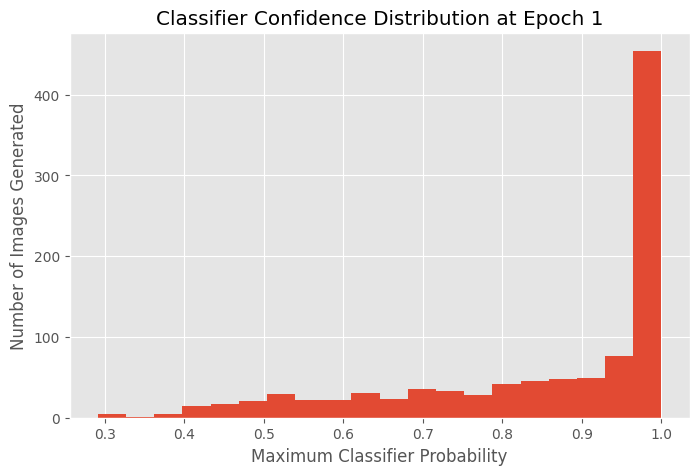

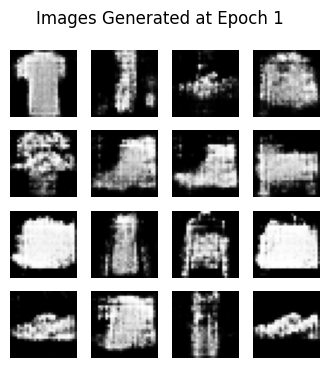

Epoch 5
Mean Classifier Confidence = 0.9050
Median Classifier Confidence = 0.9946
Minimum Classifier Confidence = 0.2567
Maximum Classifier Confidence = 1.0000
Number of Predicted Classes Represented = 10/10
Class Counts from 1000 generated images:  [ 67 104  92 115  99 110  78 103 123 109]


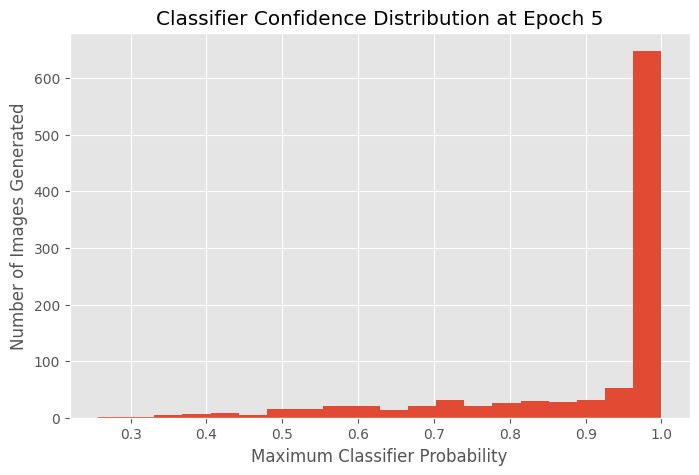

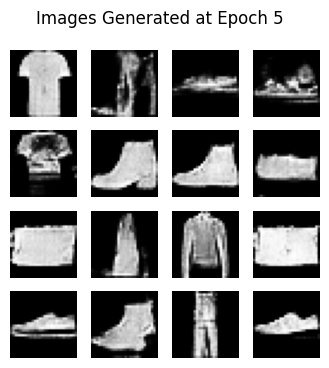

Epoch 10
Mean Classifier Confidence = 0.9159
Median Classifier Confidence = 0.9983
Minimum Classifier Confidence = 0.2701
Maximum Classifier Confidence = 1.0000
Number of Predicted Classes Represented = 10/10
Class Counts from 1000 generated images:  [ 72 112 107 121 117 102  74  83  91 121]


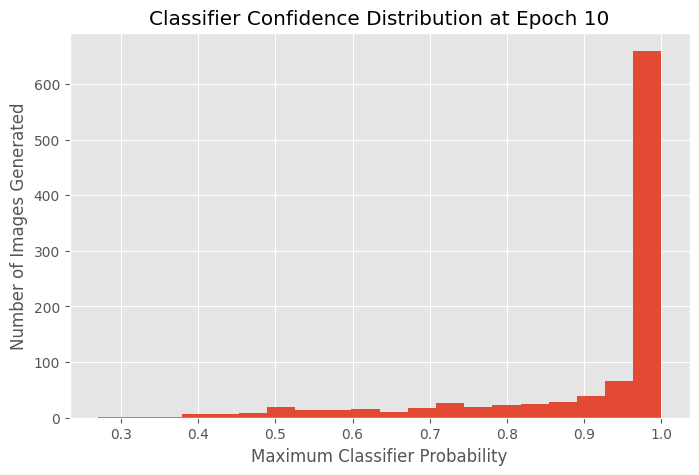

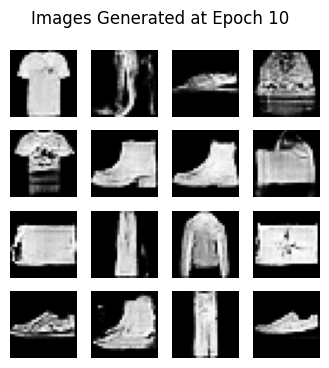

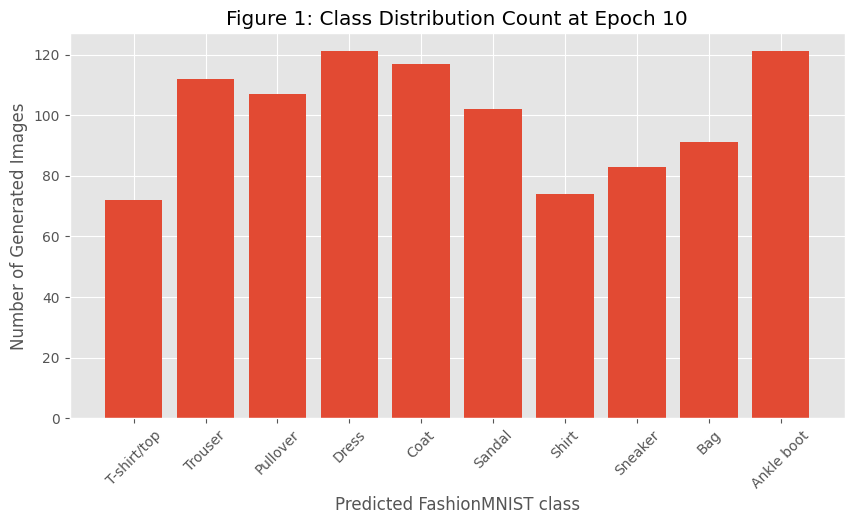

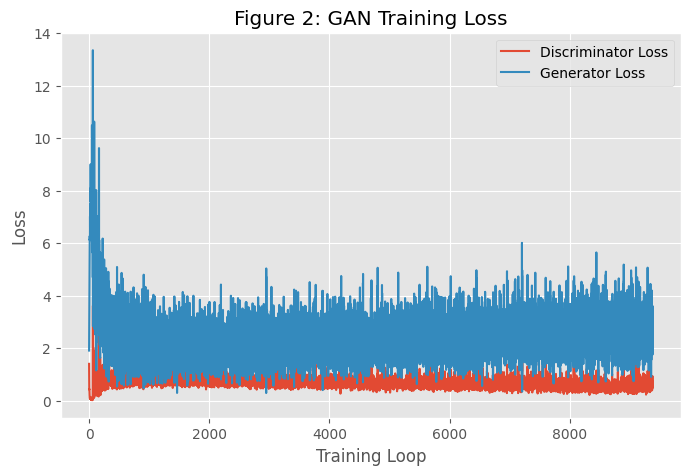

In [6]:
#Uses model from task 1 in evaluation mode, freezing parameters so weights aren't updated. Provides consistency.
classifier = model
classifier.eval()
for parameter in classifier.parameters():
    parameter.requires_grad = False

#Takes 1x28x28 and returns size 1
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=5, stride=2, padding=2),
            nn.LeakyReLU(0.25),

            nn.Conv2d(64, 128, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.25),

            nn.Conv2d(128, 256, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.25),

            nn.Flatten(),
            nn.Linear(4 * 4 * 256, 1),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        return self.layers(x)
    
#Converts random noise into 1x28x28 fake image with transposed convolution layers
class Generator(nn.Module):
    def __init__(self, noise_dim):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(noise_dim, 7 * 7 * 256),
            nn.ReLU(True),

            nn.Unflatten(1, (256, 7, 7)),
            nn.ConvTranspose2d(256, 128, 5, stride=1, padding=2),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 5, stride=2, padding=2, output_padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 1, 5, stride=2, padding=2, output_padding=1),
            nn.Tanh()
        )

    def forward(self, x):
        return self.layers(x)
    
#Initialises models, optimisers, loss functions, and tracking lists
noise_dim = 32
generator = Generator(noise_dim).to(device)
discriminator = Discriminator().to(device)

gan_criterion = nn.BCELoss()
generator_optimisier = torch.optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
discriminator_optimisier = torch.optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))
gan_epochs = 10

discriminator_losses = []
generator_losses = []

#Using 1000 for 1000 images, fixed noise so images from different epochs are comparable
evaluation_noise = torch.randn(1000, noise_dim, device=device)
evaluation_epochs = [0,4,9] #1, 5, 10

#Store results for later comparisoms
history_confidence = []
history_class_counts = []

#Generates fake images then evaluates them using Task 1 classifier at current Epoch
def generate_evaluate_images(generator, classifier, epoch, evaluation_noise):
    generator.eval()
    classifier.eval()
    with torch.no_grad():
        fake_images = generator(evaluation_noise)

        #Classifying generated images
        classifier_outputs = classifier(fake_images)

        #Converts classifier output into probabilities for each class
        probabilities = torch.softmax(classifier_outputs, dim=1)
        max_probabilites, predicted_classes = torch.max(probabilities, dim=1)
        class_counts = torch.bincount(predicted_classes, minlength=10)
        
        #Statistics for analysis
        confidence_mean = max_probabilites.mean().item()
        confidence_median = max_probabilites.median().item()
        confidence_min = max_probabilites.min().item()
        confidence_max = max_probabilites.max().item()
        num_classes_generated = torch.sum(class_counts > 0).item()

        #Get statistics
        print(f"Epoch {epoch + 1}")
        print(f"Mean Classifier Confidence = {confidence_mean:.4f}")
        print(f"Median Classifier Confidence = {confidence_median:.4f}")
        print(f"Minimum Classifier Confidence = {confidence_min:.4f}")
        print(f"Maximum Classifier Confidence = {confidence_max:.4f}")
        print(f"Number of Predicted Classes Represented = {num_classes_generated}/10")
        print("Class Counts from 1000 generated images: ", class_counts.cpu().numpy())

        #Print bar chart of confidence
        plt.figure(figsize=(8, 5))
        plt.hist(max_probabilites.cpu().numpy(), bins=20)
        plt.xlabel("Maximum Classifier Probability")
        plt.ylabel("Number of Images Generated")
        plt.title(f"Classifier Confidence Distribution at Epoch {epoch + 1}")
        plt.show()

        #Plot the first 16 images, not all 1000
        plot_images = (fake_images[:16].cpu() + 1) / 2
        plot_images = plot_images.view(plot_images.size(0), 28, 28)

        plt.figure(figsize=(4, 4))
        for i in range(min(16, plot_images.size(0))):
            plt.subplot(4, 4, i + 1)
            plt.imshow(plot_images[i], cmap="gray")
            plt.axis("off")

        plt.suptitle(f"Images Generated at Epoch {epoch + 1}")
        plt.show()

    generator.train()
    return confidence_mean, class_counts.cpu()

#Training Loop
for epoch in range(gan_epochs):
    for i, data in enumerate(train_loader):
        real_images, _ = data
        real_images = real_images.to(device)

        #Reduces need to repeatedly call 'real_images.size(0)'
        current_batch_size = real_images.size(0)
        real_labels = torch.ones(current_batch_size, 1, device=device)
        fake_labels = torch.zeros(current_batch_size, 1, device=device)

        #Trains discriminator for real image classification (0-1)
        discriminator_optimisier.zero_grad()
        real_outputs = discriminator(real_images)
        real_loss = gan_criterion(real_outputs, real_labels)

        training_noise = torch.randn(current_batch_size, noise_dim, device=device)
        fake_images = generator(training_noise)

        #Detaches fake images so generator is not updated with them
        fake_outputs = discriminator(fake_images.detach())
        fake_loss = gan_criterion(fake_outputs, fake_labels)

        discriminator_loss = fake_loss + real_loss
        discriminator_loss.backward()
        discriminator_optimisier.step()

        #Generator trained to produce images discriminator classifies as real
        generator_optimisier.zero_grad()
        fake_outputs = discriminator(fake_images)

        #Trains generator with real labels to help convince discriminator
        generator_loss = gan_criterion(fake_outputs, real_labels)
        generator_loss.backward()
        generator_optimisier.step()

        discriminator_losses.append(discriminator_loss.item())
        generator_losses.append(generator_loss.item())
    
    #Evaluates progress at evaluation_epochs to give broader view
    if epoch in evaluation_epochs:
        confidence_mean, class_counts = generate_evaluate_images(generator, classifier, epoch, evaluation_noise)
        history_class_counts.append((epoch + 1, class_counts))
        history_confidence.append((epoch + 1, confidence_mean))
        
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]
final_epoch, final_counts = history_class_counts[-1]

#Displays class distribution of generated images at final evaluation_epoch
plt.figure(figsize=(10, 5))
plt.bar(class_names, final_counts.numpy())
plt.xticks(rotation=45)
plt.xlabel("Predicted FashionMNIST class")
plt.ylabel("Number of Generated Images")
plt.title(f"Figure 1: Class Distribution Count at Epoch {final_epoch}")
plt.show()

#Display discriminator and generator loss
plt.figure(figsize=(8, 5))
plt.plot(discriminator_losses, label="Discriminator Loss")
plt.plot(generator_losses, label="Generator Loss")
plt.xlabel("Training Loop")
plt.ylabel("Loss")
plt.title("Figure 2: GAN Training Loss")
plt.legend()
plt.show()

# TASK 3 <ignore>

Task 3 attempted to improve upon the GAN built in Task 2, by changing the loss function to a `MSELoss()`, which means 'Mean Squared Error' loss. It measures the average squared difference between predicted values and the actual values, calculated by taking the squared residual averages. Residual is the difference between the actual and predicted value for each data point. Similar to `BCELoss()`, lower values produced means outputs are closer to the target labels, as differences are smaller. This was implemented by removing the `Sigmoid()` function from the discriminator and changing the `gan_criterion` to `MSELoss()`. The equation is:
<lt>$$ \text{Mean Squared Error} = \frac{1}{n} \sum_{i=1}^{n} \left(Y_i - \hat{Y}_i\right)^2 $$
where <lt>$n$ is number of observations, <lt>$Y_i$ is actual value of observation, and <lt>$\hat{Y}_i$ is predicted value of <lt>$i^{th}$ observation.

Using MSE Loss follows the LSGAN approach, replacing the sigmoid cross-entropy with a least-squares loss for the discriminator, (Mao et al., 2017) [2]. They suggest that LSGANs produce higher image quality and more stability during training. The sigmoid function is removed because it can cause vanishing gradients and LSGANs use the discriminator’s output as a real/fake score rather than a probability.

The rest of the GAN remained the same as in Task 2. The generator architecture, discriminator layers, 32-dimensional noise vector, learning rate of 0.0002, `betas(0.5, 0.999)`, Adam optimiser, batch size of 64, 10 training epochs, and evaluation method all remained unchanged. The Task 1 classifier had its parameters frozen and was not trained between experiments, ensuring the evaluation would be fair and consistent.

| Epoch 10 Statistics | Task 2: BCE GAN | Task 3: LSGAN | Difference |
|---|:---|:---|:---|
| Mean Confidence | 0.9159 | 0.9220 | +0.0061 |
| Median Confidence | 0.9983 | 0.9987 | +0.0004 |
| Minimum Confidence | 0.2701 | 0.2922 | +0.0221 |
| Maximum Confidence | 1.0000 | 1.0000 | +/- 0 |
| Classes Represented | 10/10 | 10/10 | +/- 0 |

*Table 5: Comparison of classifier confidence statistics generated at epoch 10 between Task 2 and Task 3.*

| Class | Task 2: BCE GAN | Task 3: LSGAN | Difference |
|---|:---|:---|:---|
| T-shirt/top | 72 | 78 | +6 |
| Trouser | 112 | 109 | -3 |
| Pullover | 107 | 102 | -5 |
| Dress | 121 | 77 | -44 |
| Coat | 117 | 119 | +2 |
| Sandal | 102 | 136 | +34 |
| Shirt | 74 | 78 | +4 |
| Sneaker | 83 | 88 | +5 |
| Bag | 91 | 106 | +15 |
| Ankle Boot | 121 | 107 | -14 |

*Table 6: Classification distribution comparison at epoch 10 between Task 2 and Task 3.*

The MSE Loss change provided mixed results. Classifier confidence improved slightly, with mean confidence increasing by 0.0061 and minimum confidence increasing by 0.0221, suggesting LSGAN generated slightly more recognisable images overall and improved the weakest samples. Median confidence remained almost unchanged, and both models had a maximum of 1.0000, so the quality improvement was small. However, class distribution did not improve, with the largest difference in representation rising from 49 in Task 2, to 59, indicating worse class balance. Therefore, LSGAN mainly improved classifier confidence, with diversity slightly decreasing.
Images displayed appear slightly more visually distinct than in Task 2, supporting the previous suggestion that LSGANs produce higher image quality (Mao et al., 2017), but give slightly worse distribution balances. 

A limitation is that both GANs were only evaluated once, so diversity may depend on class count generation during that training run. Repeating multiple times would allow for an average and more precise assessment.

Figure 4 shows initial LSGAN instability before losses settled. Generator loss fluctuated less and was lower than Task 2, suggesting more stability.

Epoch 1
Mean Classifier Confidence = 0.8554
Median Classifier Confidence = 0.9577
Minimum Classifier Confidence = 0.2881
Maximum Classifier Confidence = 1.0000
Number of Predicted Classes Represented = 10/10
Class Counts from 1000 generated images:  [ 50 136  66 136 128  60 141  71  65 147]


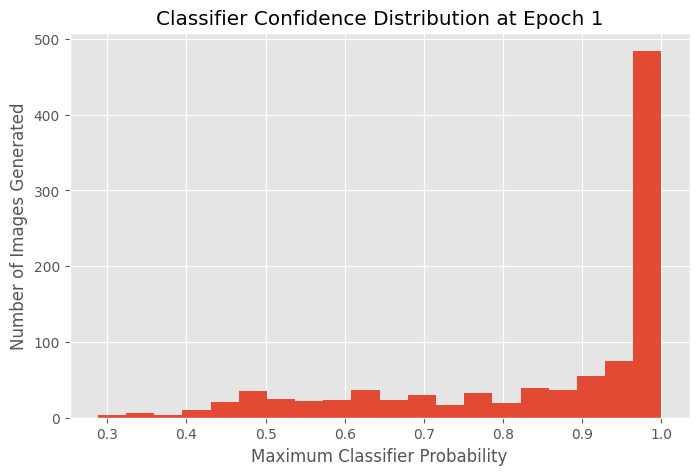

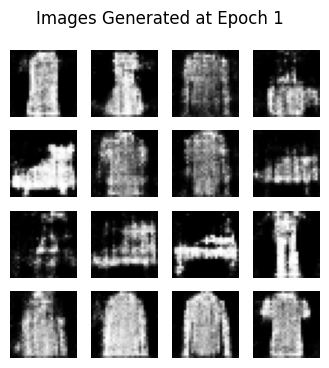

Epoch 5
Mean Classifier Confidence = 0.9170
Median Classifier Confidence = 0.9973
Minimum Classifier Confidence = 0.3087
Maximum Classifier Confidence = 1.0000
Number of Predicted Classes Represented = 10/10
Class Counts from 1000 generated images:  [ 68  94 137  68 115 107  58 105 118 130]


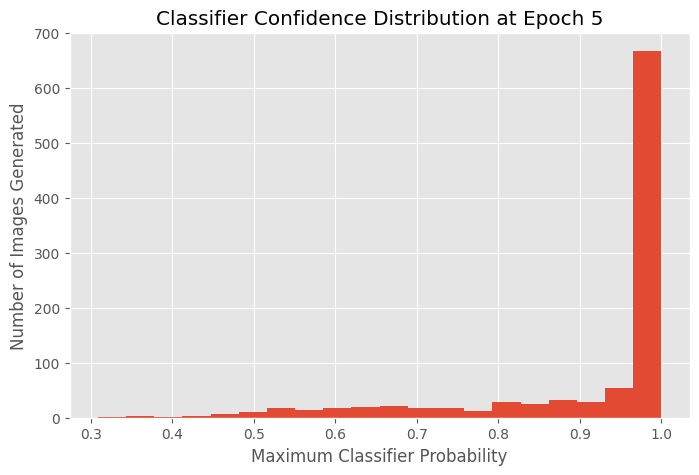

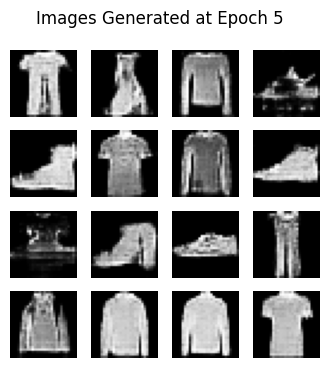

Epoch 10
Mean Classifier Confidence = 0.9220
Median Classifier Confidence = 0.9987
Minimum Classifier Confidence = 0.2922
Maximum Classifier Confidence = 1.0000
Number of Predicted Classes Represented = 10/10
Class Counts from 1000 generated images:  [ 78 109 102  77 119 136  78  88 106 107]


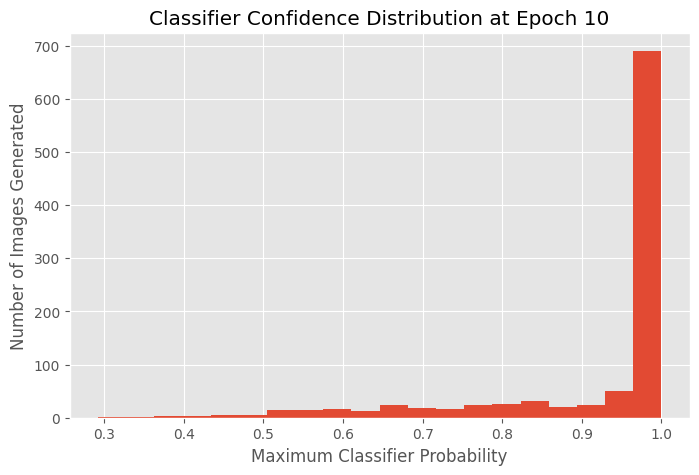

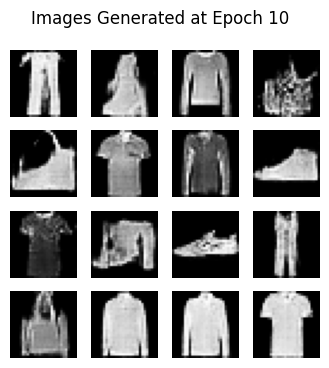

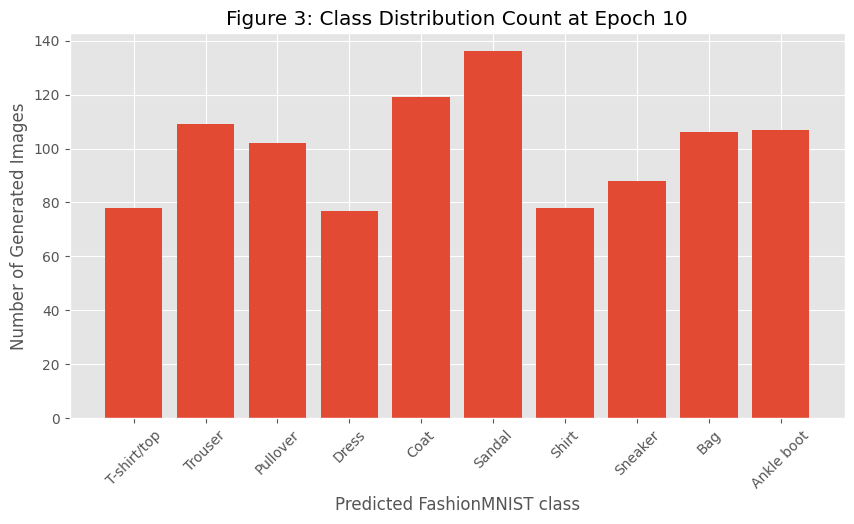

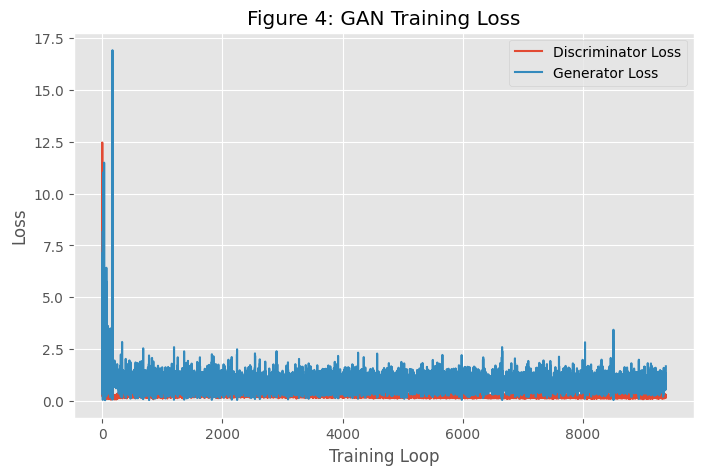

In [7]:
#Uses model from task 1 in evaluation mode, freezing parameters so weights aren't updated. Provides consistency.
classifier = model
classifier.eval()
for parameter in classifier.parameters():
    parameter.requires_grad = False

#Takes 1x28x28 and returns size 1
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=5, stride=2, padding=2),
            nn.LeakyReLU(0.25),

            nn.Conv2d(64, 128, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.25),

            nn.Conv2d(128, 256, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.25),

            nn.Flatten(),
            nn.Linear(4 * 4 * 256, 1),
            #Removing sigmoid function
        )
        
    def forward(self, x):
        return self.layers(x)
    

class Generator(nn.Module):
    def __init__(self, noise_dim):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(noise_dim, 7 * 7 * 256),
            nn.ReLU(True),

            nn.Unflatten(1, (256, 7, 7)),
            nn.ConvTranspose2d(256, 128, 5, stride=1, padding=2),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 5, stride=2, padding=2, output_padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 1, 5, stride=2, padding=2, output_padding=1),
            nn.Tanh()
        )

    def forward(self, x):
        return self.layers(x)
    
#Initialises models, optimisers, loss functions, and tracking lists
noise_dim = 32
generator = Generator(noise_dim).to(device)
discriminator = Discriminator().to(device)

#Loss function changed from BCELoss to MSELoss
gan_criterion = nn.MSELoss()
generator_optimisier = torch.optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
discriminator_optimisier = torch.optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))
gan_epochs = 10

discriminator_losses = []
generator_losses = []

#Using 1000 for 1000 images, fixed noise so images from different epochs are comparable
evaluation_noise = torch.randn(1000, noise_dim, device=device)
evaluation_epochs = [0,4,9] #1, 5, 10

#Store results for later comparisoms
history_confidence = []
history_class_counts = []

#Generates fake images then evaluates them using Task 1 classifier at current Epoch
def generate_evaluate_images(generator, classifier, epoch, evaluation_noise):
    generator.eval()
    classifier.eval()
    with torch.no_grad():
        fake_images = generator(evaluation_noise)

        #Classifying generated images
        classifier_outputs = classifier(fake_images)

        #Converts classifier output into probabilities for each class
        probabilities = torch.softmax(classifier_outputs, dim=1)
        max_probabilites, predicted_classes = torch.max(probabilities, dim=1)
        class_counts = torch.bincount(predicted_classes, minlength=10)
        
        #Statistics for analysis
        confidence_mean = max_probabilites.mean().item()
        confidence_median = max_probabilites.median().item()
        confidence_min = max_probabilites.min().item()
        confidence_max = max_probabilites.max().item()
        num_classes_generated = torch.sum(class_counts > 0).item()

        #Get statistics
        print(f"Epoch {epoch + 1}")
        print(f"Mean Classifier Confidence = {confidence_mean:.4f}")
        print(f"Median Classifier Confidence = {confidence_median:.4f}")
        print(f"Minimum Classifier Confidence = {confidence_min:.4f}")
        print(f"Maximum Classifier Confidence = {confidence_max:.4f}")
        print(f"Number of Predicted Classes Represented = {num_classes_generated}/10")
        print("Class Counts from 1000 generated images: ", class_counts.cpu().numpy())

        #Print bar chart of confidence
        plt.figure(figsize=(8, 5))
        plt.hist(max_probabilites.cpu().numpy(), bins=20)
        plt.xlabel("Maximum Classifier Probability")
        plt.ylabel("Number of Images Generated")
        plt.title(f"Classifier Confidence Distribution at Epoch {epoch + 1}")
        plt.show()

        #Plot the first 16 images, not all 1000
        plot_images = (fake_images[:16].cpu() + 1) / 2
        plot_images = plot_images.view(plot_images.size(0), 28, 28)

        plt.figure(figsize=(4, 4))
        for i in range(min(16, plot_images.size(0))):
            plt.subplot(4, 4, i + 1)
            plt.imshow(plot_images[i], cmap="gray")
            plt.axis("off")

        plt.suptitle(f"Images Generated at Epoch {epoch + 1}")
        plt.show()

    generator.train()
    return confidence_mean, class_counts.cpu()

#Training Loop
for epoch in range(gan_epochs):
    for i, data in enumerate(train_loader):
        real_images, _ = data
        real_images = real_images.to(device)

        #Reduces need to repeatedly call 'real_images.size(0)'
        current_batch_size = real_images.size(0)
        real_labels = torch.ones(current_batch_size, 1, device=device)
        fake_labels = torch.zeros(current_batch_size, 1, device=device)

        #Trains discriminator for real image classification (0-1)
        discriminator_optimisier.zero_grad()
        real_outputs = discriminator(real_images)
        real_loss = gan_criterion(real_outputs, real_labels)

        training_noise = torch.randn(current_batch_size, noise_dim, device=device)
        fake_images = generator(training_noise)

        #Detaches fake images so generator is not updated with them
        fake_outputs = discriminator(fake_images.detach())
        fake_loss = gan_criterion(fake_outputs, fake_labels)

        discriminator_loss = fake_loss + real_loss
        discriminator_loss.backward()
        discriminator_optimisier.step()

        #Generator trained to produce images discriminator classifies as real
        generator_optimisier.zero_grad()
        fake_outputs = discriminator(fake_images)

        #Trains generator with real labels to help convince discriminator
        generator_loss = gan_criterion(fake_outputs, real_labels)
        generator_loss.backward()
        generator_optimisier.step()

        discriminator_losses.append(discriminator_loss.item())
        generator_losses.append(generator_loss.item())
    
    #Evaluates progress at evaluation_epochs to give broader view
    if epoch in evaluation_epochs:
        confidence_mean, class_counts = generate_evaluate_images(generator, classifier, epoch, evaluation_noise)
        history_class_counts.append((epoch + 1, class_counts))
        history_confidence.append((epoch + 1, confidence_mean))
        
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]
final_epoch, final_counts = history_class_counts[-1]

#Displays class distribution of generated images at final evaluation_epoch
plt.figure(figsize=(10, 5))
plt.bar(class_names, final_counts.numpy())
plt.xticks(rotation=45)
plt.xlabel("Predicted FashionMNIST class")
plt.ylabel("Number of Generated Images")
plt.title(f"Figure 3: Class Distribution Count at Epoch {final_epoch}")
plt.show()

#Display discriminator and generator loss
plt.figure(figsize=(8, 5))
plt.plot(discriminator_losses, label="Discriminator Loss")
plt.plot(generator_losses, label="Generator Loss")
plt.xlabel("Training Loop")
plt.ylabel("Loss")
plt.title("Figure 4: GAN Training Loss")
plt.legend()
plt.show()

## References <ignore>

1. Kiran vutukuri, Medium (2025), '54. Training Stability in GANs: From Collapse to Convergence'. Available: "https://medium.com/core-ai/54-training-stability-in-gans-from-collapse-to-convergence-2c51d16ac42f", [Online]. Accessed: 08/05/2026.

2. Xudong Mao, Qing Li, Haoran Xie, Raymond Y.K Lau, Zhen Wang, Stephen Paul Smolley (2017), 'Least Squares Generative Adversarial Networks'. Available: "https://openaccess.thecvf.com/content_ICCV_2017/papers/Mao_Least_Squares_Generative_ICCV_2017_paper.pdf", [Online]. Accessed: 08/05/2026.

3. Alec Radford, Luke Metz, Soumith Chintala (2016), 'Unsupervised Representation Learning with Deep Convolutional Generative Adversarial Networks'. Available: "https://arxiv.org/pdf/1511.06434", [Online]. Accessed: 08/05/2026.

4. Sergey Ioffe, Christian Szegedy (2015), 'Batch Normalization: Accelerating Deep Network Training by Reducing Internal Covariate Shift'. Available: "https://static.googleusercontent.com/media/research.google.com/en//pubs/archive/43442.pdf", [Online]. Accessed: 08/05/2026.

5. Ian J. Goodfellow, Jean Pouget-Abadie, Mehdi Mirza, Bing Xu, David Warde-Farley, Sherjil Ozair, Aaron Courville, Yoshua Bengio, (2014), 'Generative Adversarial Nets'. Available: "https://proceedings.neurips.cc/paper_files/paper/2014/file/f033ed80deb0234979a61f95710dbe25-Paper.pdf", [Online]. Accessed: 08/05/2026.